# Homework Assignment — Regression and Classification: Error Analysis

This notebook presents the complete analysis for Sections 1–4. Repeated data preparation, preprocessing, and cross-validation definitions are shared across sections.


## Imports and Shared Data Preparation

In [3]:
# Core numerical, data manipulation, and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Scikit-learn utilities for preprocessing, pipelines, and grouped cross-validation
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold, cross_val_predict

# Regression models and metrics
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, fbeta_score,
    matthews_corrcoef, roc_auc_score, roc_curve
)

# Statistical properties of residuals
from scipy.stats import skew, kurtosis


In [4]:
# Load the dataset
DATA_PATH = Path("Data-Science-Course\HW1_DataScience\data") / "Full_Dataset.csv"
df = pd.read_csv(DATA_PATH)

# Convert the date and derive simple calendar features available before the match
work = df.copy()
work["Date"] = pd.to_datetime(work["Date"], errors="coerce")
work["Year"] = work["Date"].dt.year
work["Month"] = work["Date"].dt.month
work["DayOfWeek"] = work["Date"].dt.dayofweek

# Regression requires a known Team_Score; classification also requires Opponent_Score
reg = work.dropna(subset=["Team_Score"]).copy()
clf = work.dropna(subset=["Team_Score", "Opponent_Score"]).copy()

# Use the same non-leaking predictor set throughout the assignment
features = [c for c in [
    "Team", "Opponent", "Location", "Country", "Competition",
    "season", "Year", "Month", "DayOfWeek"
] if c in work.columns]

# Final-score-derived variables are deliberately excluded from the predictors
X_reg = reg[features].copy()
y_reg = reg["Team_Score"].astype(float)

# Build the binary classification target: 1 = win, 0 = draw/loss
clf["Team_Win"] = (clf["Team_Score"] > clf["Opponent_Score"]).astype(int)
X_clf = clf[features].copy()
y_clf = clf["Team_Win"].astype(int)

print("Regression observations:", len(reg))
print("Classification observations:", len(clf))
print("Features:", features)


Regression observations: 104412
Classification observations: 104412
Features: ['Team', 'Opponent', 'Location', 'Country', 'Competition', 'season', 'Year', 'Month', 'DayOfWeek']


C:\Users\nb632\AppData\Local\Temp/ipykernel_41200/326543445.py:7: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  work["Date"] = pd.to_datetime(work["Date"], errors="coerce")


In [5]:
# Separate numerical and categorical predictors
categorical_features = [
    c for c in features
    if X_reg[c].dtype == "object" or str(X_reg[c].dtype).startswith("category")
]
numeric_features = [c for c in features if c not in categorical_features]

# Numerical missing values are replaced by the median.
# Categorical missing values use the most frequent category and are one-hot encoded.
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

# Each physical match appears from two team perspectives.
# A date + unordered team pair is therefore used as the cross-validation group.
def make_match_groups(frame):
    a = frame["Team"].astype(str)
    b = frame["Opponent"].astype(str)
    pair = np.where(a <= b, a + "||" + b, b + "||" + a)
    return pd.Series(frame["Date"].astype(str) + "||" + pair, index=frame.index)

groups_reg = make_match_groups(reg)
groups_clf = make_match_groups(clf)

# Five folds provide large train/validation samples while keeping the cost of
# repeatedly fitting several models manageable. Grouping prevents match leakage.
cv = GroupKFold(n_splits=5)


### Cross-Validation Choice

All analyses use 5-fold GroupKFold cross-validation. The dataset contains more than 100,000 team-perspective observations, so five folds provide large training and validation samples while keeping the computational cost of fitting multiple models manageable. Grouping by physical match prevents the two rows representing the same match from being split between training and validation. This provides a practical balance between validation variability and computational complexity.


# 1. Regression Error Analysis

## 1.1 Residual Analysis

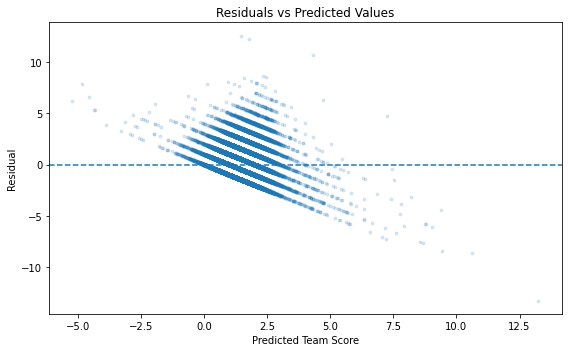

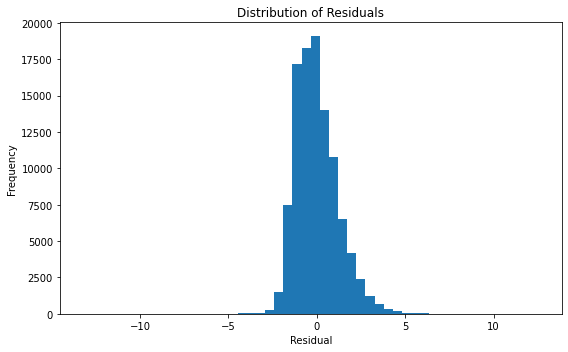

Mean residual: 0.002716819055473113


In [6]:
# Baseline regression model used for the error analysis
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Obtain out-of-fold predictions so every residual is based on an unseen validation observation
reg_pred = cross_val_predict(
    linear_pipeline, X_reg, y_reg,
    cv=cv, groups=groups_reg, n_jobs=-1
)

# Residual = actual value - predicted value
reg_results = reg.copy()
reg_results["Predicted_Team_Score"] = reg_pred
reg_results["Residual"] = y_reg.to_numpy() - reg_pred
reg_results["Absolute_Error"] = np.abs(reg_results["Residual"])

# Residuals as a function of predicted values
plt.figure(figsize=(8, 5))
plt.scatter(reg_results["Predicted_Team_Score"], reg_results["Residual"], alpha=0.15, s=8)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Team Score")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.show()

# Residual distribution
plt.figure(figsize=(8, 5))
plt.hist(reg_results["Residual"], bins=50)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.tight_layout()
plt.show()

print("Mean residual:", reg_results["Residual"].mean())


**Are the residuals centered around zero?**  
Yes. The mean residual is approximately 0.003, indicating no substantial overall tendency toward overprediction or underprediction.

**Do the residuals exhibit any systematic patterns?**  
Yes. The residual plot shows parallel diagonal bands because the actual goal count is discrete while Linear Regression produces continuous predictions.

**Is there evidence of heteroscedasticity?**  
The residual spread is not a perfectly constant random cloud, so the homoskedasticity assumption is not fully supported. However, part of the visible structure is caused by the discrete target.

**Is there a sector that is more likely to have high error rates? If so, why?**  
Yes. The subgroup analysis shows higher errors for home observations and for some competitions, especially the FA Cup. These differences suggest that prediction difficulty depends on match context. The model also produces some unrealistic negative or very large goal predictions, illustrating a limitation of Linear Regression for this target.


## 1.2 Error as a Function of Features

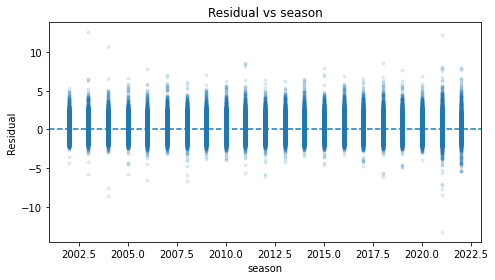

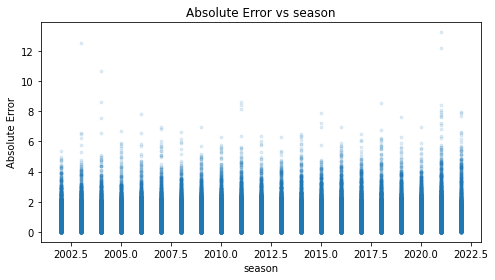

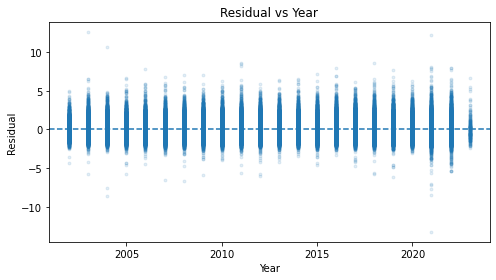

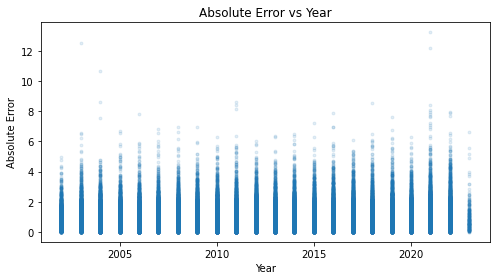

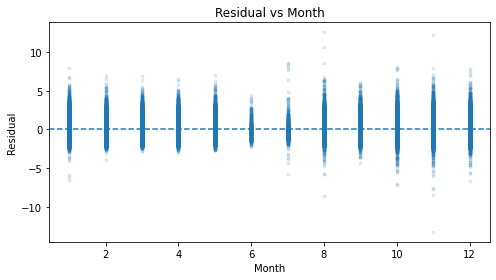

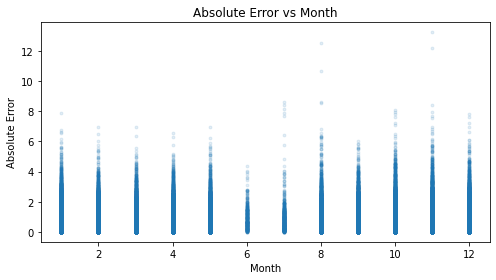

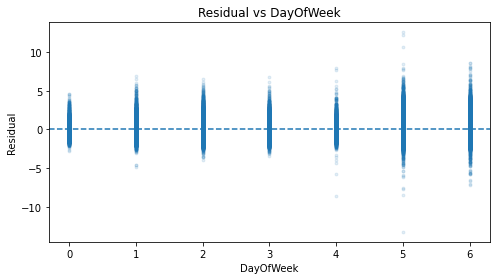

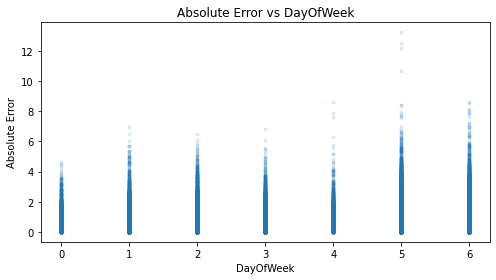


Mean Absolute Error by Team


,MAE,Count
Team,,
MILTON KEYNES DONS,1.3352,54
BAYERN MUNICH,1.3074,994
BARCELONA,1.2681,1115
REAL MADRID,1.2341,1090
BRADFORD,1.2033,50
MANCHESTER CITY,1.2022,974
DONCASTER,1.1686,51
PARIS SAINT GERMAIN,1.1658,981
RB LEIPZIG,1.1594,301



Mean Absolute Error by Opponent


,MAE,Count
Opponent,,
GENK,1.3121,60
TRANMERE,1.2670,57
BATE BORISOV,1.2587,60
NOTTINGHAM FOREST,1.2317,65
PLYMOUTH,1.1961,51
BENEVENTO,1.1904,97
ALEMANNIA AACHEN,1.1788,62
PESCARA,1.1643,105
LUTON,1.1614,63



Mean Absolute Error by Location


,MAE,Count
Location,,
Home,0.9805,52206
Away,0.8888,52206



Mean Absolute Error by Country


,MAE,Count
Country,,
germany,0.9914,15092
france,0.9430,20302
england,0.9385,21760
europe-uefa,0.9346,10232
spain,0.9151,19280
italy,0.8937,17746



Mean Absolute Error by Competition


,MAE,Count
Competition,,
fa-cup,1.0395,20024
bundesliga,0.9687,12510
uefa-champions-league,0.9457,5052
uefa-europa-league,0.9237,5180
premier-league,0.9130,15552
primera-division,0.9040,15516
serie-a,0.8884,15238
ligue-1,0.8692,15340


In [7]:
# Numerical/calendar features: residual and absolute-error behavior
numeric_error_features = [
    c for c in ["season", "Year", "Month", "DayOfWeek"]
    if c in reg_results.columns
]

for feature in numeric_error_features:
    # Residuals versus the selected feature
    plt.figure(figsize=(7, 4))
    plt.scatter(
        reg_results[feature],
        reg_results["Residual"],
        alpha=0.12,
        s=8
    )
    plt.axhline(0, linestyle="--")
    plt.xlabel(feature)
    plt.ylabel("Residual")
    plt.title(f"Residual vs {feature}")
    plt.tight_layout()
    plt.show()

    # Absolute error versus the same feature
    plt.figure(figsize=(7, 4))
    plt.scatter(
        reg_results[feature],
        reg_results["Absolute_Error"],
        alpha=0.12,
        s=8
    )
    plt.xlabel(feature)
    plt.ylabel("Absolute Error")
    plt.title(f"Absolute Error vs {feature}")
    plt.tight_layout()
    plt.show()

# Categorical features are summarized by subgroup MAE.
# A minimum count of 50 reduces emphasis on very small groups.
# For high-cardinality Team/Opponent features, only the top 10 groups are displayed.
for feature in [
    c for c in ["Team", "Opponent", "Location", "Country", "Competition"]
    if c in reg_results.columns
]:
    table = (
        reg_results.groupby(feature)["Absolute_Error"]
        .agg(MAE="mean", Count="size")
        .query("Count >= 50")
        .sort_values("MAE", ascending=False)
    )

    if feature in ["Team", "Opponent"]:
        table = table.head(10)

    print(f"\nMean Absolute Error by {feature}")
    display(table.round(4))


The calendar features do not show a strong systematic relationship with the direction of the residuals, although the spread and extreme values vary somewhat across periods. Clearer feature-dependent errors appear in the categorical variables. Home observations have a higher MAE than away observations (0.981 vs 0.889). Germany has the highest country-level MAE (0.991), while Italy has the lowest among the displayed countries (0.894). The FA Cup has the highest competition-level MAE (1.039), compared with 0.869 for Ligue 1. These results indicate subgroup-dependent prediction difficulty.


## 1.3 Analysis of Extreme Errors

In [8]:
# Define extreme errors as the largest 5% of absolute errors
extreme_threshold = reg_results["Absolute_Error"].quantile(0.95)
extreme = reg_results[reg_results["Absolute_Error"] >= extreme_threshold].copy()

print("95th percentile absolute-error threshold:", extreme_threshold)
print("Number of extreme observations:", len(extreme))
print("Overall MAE:", reg_results["Absolute_Error"].mean())
print("Extreme-subset MAE:", extreme["Absolute_Error"].mean())

# Display only the most relevant columns for the ten largest errors
display(
    extreme.sort_values("Absolute_Error", ascending=False)[[
        "Date", "Team", "Opponent", "Location", "Country", "Competition",
        "Team_Score", "Predicted_Team_Score", "Residual", "Absolute_Error"
    ]].head(10).round(4)
)

# Compare subgroup representation in the full data and in the extreme-error subset
for feature in [c for c in ["Location", "Country", "Competition", "season"] if c in reg_results.columns]:
    all_share = reg_results[feature].value_counts(normalize=True)
    extreme_share = extreme[feature].value_counts(normalize=True)
    comparison = pd.concat([all_share, extreme_share], axis=1).fillna(0)
    comparison.columns = ["All_Data", "Extreme_Errors"]
    comparison["Difference"] = comparison["Extreme_Errors"] - comparison["All_Data"]
    print(f"\nExtreme-error representation by {feature}")
    display(comparison.sort_values("Difference", ascending=False).head(10).round(4))


95th percentile absolute-error threshold: 2.2961524143273384
Number of extreme observations: 5221
Overall MAE: 0.934675849822362
Extreme-subset MAE: 3.0846369051699143


,Date,Team,Opponent,Location,Country,Competition,Team_Score,Predicted_Team_Score,Residual,Absolute_Error
101388,2021-11-13,ASC OUEST,CSC DE CAYENNE,Home,france,fa-cup,0.0,13.2433,-13.2433,13.2433
98122,2003-08-30,WACKER BURGHAUSEN,TSV GERBRUNN,Away,germany,fa-cup,14.0,1.4485,12.5515,12.5515
101444,2021-11-27,PARIS FC,CSC DE CAYENNE,Home,france,fa-cup,14.0,1.7950,12.2050,12.2050
98187,2004-08-21,FC KAISERSLAUTERN,FC SCHONBERG 95,Away,germany,fa-cup,15.0,4.3019,10.6981,10.6981
98627,2011-07-31,FC SCHALKE 04,FC TENINGEN,Away,germany,fa-cup,11.0,2.3559,8.6441,8.6441
98172,2004-08-20,FC NURNBERG,FC TENINGEN,Away,germany,fa-cup,2.0,10.5998,-8.5998,8.5998
99064,2018-08-19,BORUSSIA MONCHENGLADBACH,BSC HASTEDT,Away,germany,fa-cup,11.0,2.4564,8.5436,8.5436
101419,2021-11-20,PLANCOET ARGUENON,JUMEAUX MZOUASIA,Home,france,fa-cup,1.0,9.4271,-8.4271,8.4271
98608,2011-07-30,SC PADERBORN 07,ROT-WEISS AHLEN,Away,germany,fa-cup,10.0,1.5815,8.4185,8.4185
98618,2011-07-31,SpVgg GREUTHER FURTH,EIMSBUTTELER TV,Away,germany,fa-cup,10.0,1.8602,8.1398,8.1398



Extreme-error representation by Location


,All_Data,Extreme_Errors,Difference
Location,,,
Home,0.5,0.5623,0.0623
Away,0.5,0.4377,-0.0623



Extreme-error representation by Country


,All_Data,Extreme_Errors,Difference
Country,,,
germany,0.1445,0.1710,0.0265
france,0.1944,0.2166,0.0222
spain,0.1847,0.1852,0.0006
europe-uefa,0.0980,0.0946,-0.0034
england,0.2084,0.2011,-0.0073
italy,0.1700,0.1314,-0.0386



Extreme-error representation by Competition


,All_Data,Extreme_Errors,Difference
Competition,,,
fa-cup,0.1918,0.2950,0.1032
bundesliga,0.1198,0.1270,0.0072
uefa-champions-league,0.0484,0.0481,-0.0003
uefa-europa-league,0.0496,0.0465,-0.0031
primera-division,0.1486,0.1394,-0.0092
premier-league,0.1489,0.1232,-0.0258
serie-a,0.1459,0.1099,-0.0360
ligue-1,0.1469,0.1109,-0.0360



Extreme-error representation by season


,All_Data,Extreme_Errors,Difference
season,,,
2022,0.0265,0.0475,0.0210
2021,0.0534,0.0726,0.0191
2016,0.0505,0.0571,0.0066
2017,0.0507,0.0538,0.0031
2011,0.0504,0.0534,0.0030
2020,0.0506,0.0517,0.0011
2019,0.0491,0.0496,0.0005
2003,0.0424,0.0427,0.0003
2010,0.0504,0.0502,-0.0002


The top 5% of absolute errors begin at approximately 2.296 goals and contain 5,221 observations. Their MAE is approximately 3.085 goals, compared with 0.935 for the full dataset. Home observations are overrepresented in the extreme subset by about 6.23 percentage points. The FA Cup shows the strongest competition effect: it represents about 19.18% of all observations but about 29.50% of extreme errors. Germany and France are also moderately overrepresented, while the 2021–2022 seasons show smaller increases.

**Data quality issues:**  
The inspected extreme observations do not provide sufficient evidence that data-quality problems are the main source of error.

**Model limitations:**  
Model limitations clearly contribute. Linear Regression is not naturally constrained to a non-negative discrete goal count and cannot fully capture complex nonlinear relationships or interactions.

**Rare or exceptional cases:**  
Some extreme observations are consistent with unusual match outcomes. Therefore, the largest errors are best explained by a combination of model limitations and exceptional cases rather than by demonstrated data-quality problems.


## 1.4 Statistical Properties of Errors

In [9]:
# Required statistical error measures
error_statistics = pd.Series({
    "MAE": mean_absolute_error(y_reg, reg_pred),
    "Residual standard deviation": reg_results["Residual"].std(),
    "Skewness": skew(reg_results["Residual"], bias=False),
    "Excess kurtosis": kurtosis(reg_results["Residual"], bias=False)
})
display(error_statistics.to_frame("Value").round(4))


,Value
MAE,0.9347
Residual standard deviation,1.2012
Skewness,0.8057
Excess kurtosis,1.9443


The MAE is 0.935 goals and the residual standard deviation is 1.201. Positive skewness (0.806) indicates a longer positive tail, corresponding to cases where the model substantially underpredicts the actual score. The excess kurtosis (1.944) indicates heavier tails than a normal distribution and a greater occurrence of extreme errors. These statistics are consistent with the residual and extreme-error analyses.


# 2. Regression Models

## Model Comparison

In [10]:
# Required models. All use exactly the same predictors and preprocessing.
regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=12, min_samples_leaf=10, random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, max_depth=12, min_samples_leaf=5,
        random_state=42, n_jobs=-1
    )
}

summary_rows = []
fold_rows = []
model_oof = {}

# Evaluate every model on the same five grouped folds
for model_name, estimator in regression_models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    oof = np.full(len(y_reg), np.nan)
    train_mae = []
    validation_mae = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_reg, y_reg, groups_reg), 1):
        model = clone(pipeline)
        model.fit(X_reg.iloc[train_idx], y_reg.iloc[train_idx])

        train_pred = model.predict(X_reg.iloc[train_idx])
        val_pred = model.predict(X_reg.iloc[val_idx])
        oof[val_idx] = val_pred

        tr_mae = mean_absolute_error(y_reg.iloc[train_idx], train_pred)
        va_mae = mean_absolute_error(y_reg.iloc[val_idx], val_pred)
        va_mse = mean_squared_error(y_reg.iloc[val_idx], val_pred)
        va_rmse = np.sqrt(va_mse)
        va_r2 = r2_score(y_reg.iloc[val_idx], val_pred)

        train_mae.append(tr_mae)
        validation_mae.append(va_mae)
        fold_rows.append({
            "Model": model_name, "Fold": fold,
            "Train_MAE": tr_mae, "Validation_MAE": va_mae,
            "MSE": va_mse, "RMSE": va_rmse, "R2": va_r2
        })

    model_oof[model_name] = oof
    mse = mean_squared_error(y_reg, oof)
    summary_rows.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_reg, oof),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_reg, oof),
        "Mean_Train_MAE": np.mean(train_mae),
        "Mean_Validation_MAE": np.mean(validation_mae),
        "Validation_MAE_Std": np.std(validation_mae)
    })

regression_summary = pd.DataFrame(summary_rows).set_index("Model")
fold_results = pd.DataFrame(fold_rows)

display(regression_summary.round(4))
display(fold_results.round(4))


,MAE,MSE,RMSE,R2,Mean_Train_MAE,Mean_Validation_MAE,Validation_MAE_Std
Model,,,,,,,
Linear Regression,0.9347,1.4429,1.2012,0.0899,0.8827,0.9347,0.0059
Decision Tree,0.9568,1.4983,1.2240,0.0550,0.9404,0.9568,0.0074
Random Forest,0.9506,1.4710,1.2128,0.0722,0.9333,0.9506,0.0068


,Model,Fold,Train_MAE,Validation_MAE,MSE,RMSE,R2
0,Linear Regression,1,0.8836,0.9288,1.4206,1.1919,0.0860
1,Linear Regression,2,0.8834,0.9336,1.4261,1.1942,0.0894
2,Linear Regression,3,0.8818,0.9401,1.4805,1.2168,0.0870
3,Linear Regression,4,0.8842,0.9280,1.4110,1.1878,0.0991
4,Linear Regression,5,0.8808,0.9429,1.4761,1.2150,0.0880
5,Decision Tree,1,0.9416,0.9460,1.4603,1.2084,0.0605
6,Decision Tree,2,0.9412,0.9543,1.4839,1.2182,0.0524
7,Decision Tree,3,0.9378,0.9633,1.5383,1.2403,0.0514
8,Decision Tree,4,0.9419,0.9534,1.4786,1.2160,0.0559
9,Decision Tree,5,0.9397,0.9668,1.5302,1.2370,0.0546


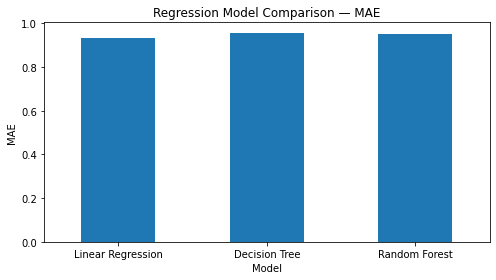

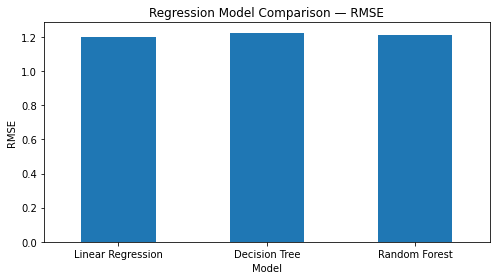

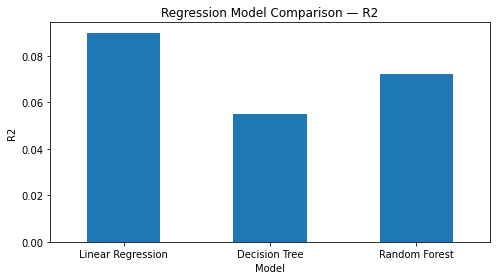

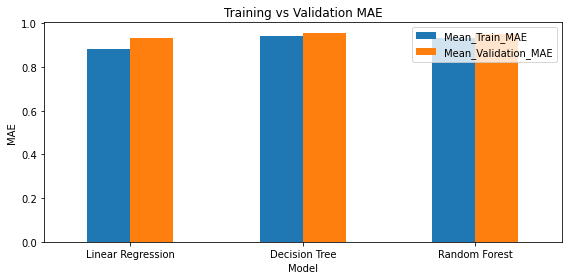

In [11]:
# Compact visual comparison of the required evaluation metrics
for metric in ["MAE", "RMSE", "R2"]:
    plt.figure(figsize=(7, 4))
    regression_summary[metric].plot(kind="bar")
    plt.ylabel(metric)
    plt.title(f"Regression Model Comparison — {metric}")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Compare training and validation MAE to inspect generalization behavior
regression_summary[["Mean_Train_MAE", "Mean_Validation_MAE"]].plot(
    kind="bar", figsize=(8, 4)
)
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


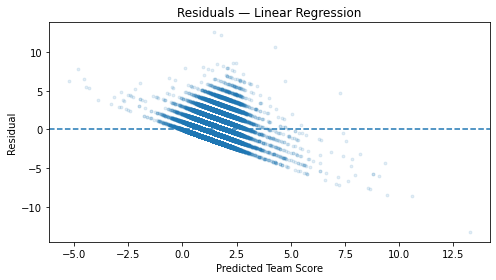

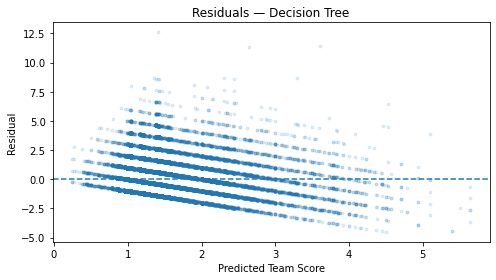

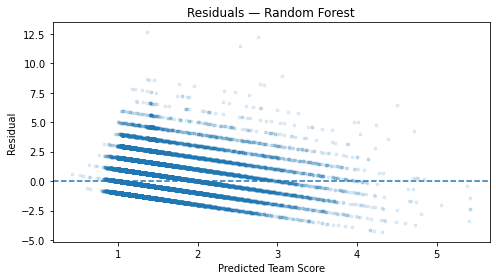

In [12]:
# Residual behavior for the three evaluated models
for model_name, predictions in model_oof.items():
    residuals = y_reg.to_numpy() - predictions
    plt.figure(figsize=(7, 4))
    plt.scatter(predictions, residuals, alpha=0.12, s=8)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted Team Score")
    plt.ylabel("Residual")
    plt.title(f"Residuals — {model_name}")
    plt.tight_layout()
    plt.show()


## Discussion

Linear Regression achieved the best validation performance across all reported metrics (MAE 0.9347, MSE 1.4429, RMSE 1.2012, and R² 0.0899). Random Forest ranked second (MAE 0.9506, RMSE 1.2128, R² 0.0722), followed by the Decision Tree (MAE 0.9568, RMSE 1.2240, R² 0.0550). Linear Regression was also best in every fold, and all models had small validation-MAE standard deviations, indicating a stable comparison. The low R² values for all models show that substantial target variability remains unexplained by the available feature set.

Linear Regression assumes an additive linear relationship and is not naturally constrained to non-negative count predictions. Its residuals are centered near zero, but their structured bands, heavy tails, and varying spread show that the error behavior does not fully match ideal linear-model assumptions. Full independence is also not guaranteed because observations can share teams and time periods; GroupKFold specifically prevents the two perspectives of the same physical match from leaking across training and validation. Tree-based models do not require linearity or homoskedastic residuals and can capture nonlinear interactions.

The Decision Tree has similar training and validation MAE (0.9404 vs 0.9568), so there is no evidence of severe overfitting under the chosen depth and leaf-size constraints; its relatively high training error and weakest validation performance are consistent with substantial bias under these settings. Random Forest improves on the single tree, consistent with averaging multiple trees to reduce instability, but it remains worse than the linear baseline. Linear Regression has the largest train-validation MAE difference, yet it has the lowest validation error and the lowest fold-to-fold validation-MAE variability, so the gap alone does not indicate that it has the highest variance.

Least-squares Linear Regression is sensitive to large residuals, which is relevant because the error analysis identified heavy tails and extreme matches. A single tree can also be sensitive to noise and small data changes, while Random Forest reduces this instability through averaging. Linear Regression is most limited when relationships are nonlinear or when the target constraints matter; the negative/unrealistic score predictions illustrate this limitation. Trees provide advantages when nonlinearities and interactions dominate and, in this dataset, their predictions remain within a more natural score range. However, this did not translate into better predictive metrics.

For future analysis among the evaluated models, Linear Regression is preferred because it produced the best and most stable validation performance while remaining relatively interpretable. The main modeling insight is that additional model complexity did not automatically improve prediction: Random Forest improved on the individual tree but did not outperform the simpler baseline.


# 3. Classification Error Analysis

In [13]:
# Show the class balance before evaluating the classifier
class_distribution = pd.DataFrame({
    "Count": y_clf.value_counts().sort_index(),
    "Proportion": y_clf.value_counts(normalize=True).sort_index()
})
class_distribution.index = ["Non-win", "Win"]
display(class_distribution.round(4))

# Logistic Regression produces win probabilities; the default decision threshold is 0.5
classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000, solver="liblinear", random_state=42
    ))
])

# Generate out-of-fold probabilities so each classification result is evaluated on unseen data
oof_probability = np.full(len(y_clf), np.nan)
fold_indices = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_clf, y_clf, groups_clf), 1):
    model = clone(classifier)
    model.fit(X_clf.iloc[train_idx], y_clf.iloc[train_idx])
    oof_probability[val_idx] = model.predict_proba(X_clf.iloc[val_idx])[:, 1]
    fold_indices.append((fold, val_idx))

oof_prediction = (oof_probability >= 0.5).astype(int)

classification_results = clf[[
    "Team", "Opponent", "Location", "Country", "Competition",
    "season", "Team_Score", "Opponent_Score"
]].copy()
classification_results["Actual"] = y_clf.to_numpy()
classification_results["Predicted"] = oof_prediction
classification_results["Win_Probability"] = oof_probability
classification_results["Correct"] = (
    classification_results["Actual"] == classification_results["Predicted"]
)


,Count,Proportion
Non-win,65617,0.6284
Win,38795,0.3716


## 3.1 Confusion Matrix Analysis

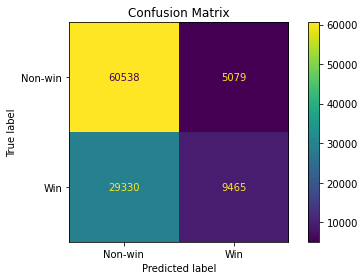

,Count
True Negative,60538
False Positive,5079
False Negative,29330
True Positive,9465


Win precision: 0.6508
Win recall: 0.244


In [14]:
# Confusion matrix at the default threshold of 0.5
cm = confusion_matrix(y_clf, oof_prediction)
ConfusionMatrixDisplay(cm, display_labels=["Non-win", "Win"]).plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
confusion_summary = pd.DataFrame(
    {"Count": [tn, fp, fn, tp]},
    index=["True Negative", "False Positive", "False Negative", "True Positive"]
)
display(confusion_summary)

# Report the two key positive-class measures used in the interpretation
print("Win precision:", round(precision_score(y_clf, oof_prediction), 4))
print("Win recall:", round(recall_score(y_clf, oof_prediction), 4))


At threshold 0.5, the confusion matrix contains 60,538 true negatives, 5,079 false positives, 29,330 false negatives, and 9,465 true positives. The classifier therefore strongly favors the non-win class. Its precision for predicted wins is 65.1%, while recall for actual wins is only 24.4%.

**Which type of error is most critical in this context?**  
False negatives are the dominant and most critical error in this analysis. There are 29,330 false negatives compared with only 5,079 false positives, meaning that many actual wins are missed by the classifier.

**In which regions does the model fail systematically?**  
The subgroup analysis in Section 3.3 shows that errors are not uniform. Home observations have the highest location-based error rate (37.19% compared with 28.72% for away observations), and some competitions such as the FA Cup also show higher error rates.

**What insights can be derived from the analysis?**  
The default threshold of 0.5 is too conservative if detecting wins is important. The model predicts non-win much more readily than win, which produces relatively high precision for predicted wins but very low recall. This motivates the threshold analysis in Section 3.4.


## 3.2 Probability-Based Analysis

,count,mean,median,std
Correct,,,,
Incorrect,34409,0.6255,0.6032,0.085
Correct,70003,0.6691,0.6800,0.098


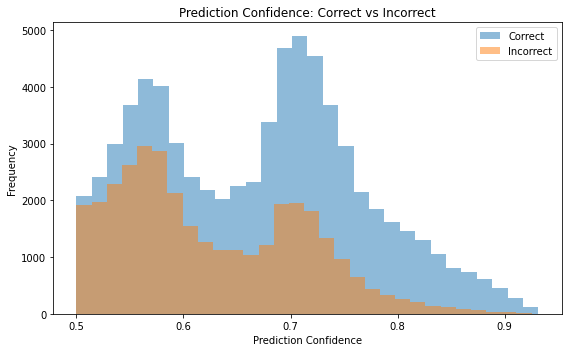

High-confidence errors: 900
Percentage of observations: 0.862 %


,Team,Opponent,Location,Competition,Team_Score,Opponent_Score,Actual,Predicted,Win_Probability,Confidence
12771,MALAGA,BARCELONA,Away,primera-division,1.0,0.0,1,0,0.0747,0.9253
13325,ALAVES,BARCELONA,Away,primera-division,2.0,1.0,1,0,0.0762,0.9238
10492,ESPANYOL,BARCELONA,Away,primera-division,2.0,1.0,1,0,0.0762,0.9238
27109,SUNDERLAND,CHELSEA,Away,premier-league,3.0,0.0,1,0,0.0789,0.9211
10625,OSASUNA,BARCELONA,Away,primera-division,1.0,0.0,1,0,0.0791,0.9209
78953,DEPORTIVO LA CORUNA,BAYERN MUNICH,Away,uefa-champions-league,3.0,2.0,1,0,0.0798,0.9202
54254,AJACCIO,PARIS SAINT GERMAIN,Away,ligue-1,4.0,2.0,1,0,0.0819,0.9181
8422,DEPORTIVO LA CORUNA,BARCELONA,Away,primera-division,2.0,0.0,1,0,0.0824,0.9176
89930,LEGANES,REAL MADRID,Away,fa-cup,2.0,1.0,1,0,0.0840,0.9160
8261,DEPORTIVO LA CORUNA,BARCELONA,Away,primera-division,4.0,2.0,1,0,0.0843,0.9157


In [15]:
# Confidence is the probability assigned to the class that the model actually predicted
classification_results["Confidence"] = np.where(
    classification_results["Predicted"] == 1,
    classification_results["Win_Probability"],
    1 - classification_results["Win_Probability"]
)

confidence_summary = classification_results.groupby("Correct")["Confidence"].agg(
    ["count", "mean", "median", "std"]
)
confidence_summary.index = confidence_summary.index.map({
    False: "Incorrect", True: "Correct"
})
display(confidence_summary.round(4))

# Compare confidence distributions for correct and incorrect predictions
plt.figure(figsize=(8, 5))
plt.hist(
    classification_results.loc[classification_results["Correct"], "Confidence"],
    bins=30, alpha=0.5, label="Correct"
)
plt.hist(
    classification_results.loc[~classification_results["Correct"], "Confidence"],
    bins=30, alpha=0.5, label="Incorrect"
)
plt.xlabel("Prediction Confidence")
plt.ylabel("Frequency")
plt.title("Prediction Confidence: Correct vs Incorrect")
plt.legend()
plt.tight_layout()
plt.show()

# Identify incorrect predictions made with at least 80% confidence
high_confidence_errors = classification_results[
    (~classification_results["Correct"]) &
    (classification_results["Confidence"] >= 0.80)
].copy()

print("High-confidence errors:", len(high_confidence_errors))
print(
    "Percentage of observations:",
    round(100 * len(high_confidence_errors) / len(classification_results), 3), "%"
)
display(
    high_confidence_errors.sort_values("Confidence", ascending=False)[[
        "Team", "Opponent", "Location", "Competition",
        "Team_Score", "Opponent_Score", "Actual",
        "Predicted", "Win_Probability", "Confidence"
    ]].head(10).round(4)
)


Correct predictions have higher average confidence than incorrect predictions (0.669 vs 0.626), but the distributions overlap substantially, so confidence alone does not reliably separate correct from incorrect cases.

**High-confidence errors:**  
There are 900 high-confidence errors, representing 0.862% of observations. Several of the most confident errors are false negatives in which the model assigns a very low win probability to a team that nevertheless wins. These cases show that high model confidence does not guarantee correctness.


## 3.3 Error as a Function of Features

In [16]:
# Compare compact misclassification rates for the required subgroup analysis
for feature in [c for c in ["Location", "Country", "Competition", "season"] if c in classification_results.columns]:
    table = pd.crosstab(
        classification_results[feature],
        classification_results["Correct"],
        normalize="index"
    ).rename(columns={False: "Incorrect_Rate", True: "Correct_Rate"})

    if "Incorrect_Rate" in table.columns:
        table = table.sort_values("Incorrect_Rate", ascending=False)

    # Seasons are numerous, so only the ten highest-error seasons are displayed.
    display_table = table.head(10) if feature == "season" else table
    print(f"\nError rate by {feature}")
    display(display_table.round(4))



Error rate by Location


Correct,Incorrect_Rate,Correct_Rate
Location,,
Home,0.3719,0.6281
Away,0.2872,0.7128



Error rate by Country


Correct,Incorrect_Rate,Correct_Rate
Country,,
germany,0.3452,0.6548
france,0.3368,0.6632
england,0.3307,0.6693
europe-uefa,0.3269,0.6731
spain,0.3195,0.6805
italy,0.3189,0.6811



Error rate by Competition


Correct,Incorrect_Rate,Correct_Rate
Competition,,
fa-cup,0.3519,0.6481
uefa-europa-league,0.3479,0.6521
bundesliga,0.3429,0.6571
ligue-1,0.3316,0.6684
premier-league,0.3183,0.6817
primera-division,0.3158,0.6842
serie-a,0.3144,0.6856
uefa-champions-league,0.3054,0.6946



Error rate by season


Correct,Incorrect_Rate,Correct_Rate
season,,
2022,0.3514,0.6486
2002,0.3422,0.6578
2010,0.3378,0.6622
2020,0.3374,0.6626
2021,0.3366,0.6634
2009,0.3352,0.6648
2003,0.3352,0.6648
2008,0.3344,0.6656
2007,0.3319,0.6681


Misclassification is not uniform across subgroups. The strongest difference is by location: the error rate is 37.19% for home observations and 28.72% for away observations. Country-level differences are smaller, ranging from 34.52% in Germany to 31.89% in Italy. The FA Cup has the highest displayed competition error rate (35.19%), while the UEFA Champions League has the lowest (30.54%). Error rates also vary by season, but the results do not show a clear chronological trend.

These results identify home observations and some competition groups as regions that are more prone to misclassification.


## 3.4 Threshold Sensitivity Analysis

,Threshold,Precision,Recall,F1
0,0.1,0.3730,0.9990,0.5432
1,0.2,0.3926,0.9775,0.5602
2,0.3,0.4495,0.7973,0.5749
3,0.4,0.5117,0.5902,0.5481
4,0.5,0.6508,0.2440,0.3549
5,0.6,0.7117,0.1061,0.1847
6,0.7,0.7789,0.0307,0.0591
7,0.8,0.8071,0.0029,0.0058
8,0.9,0.0000,0.0000,0.0000


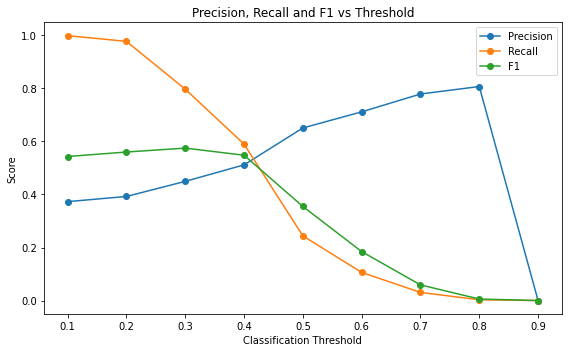

In [17]:
# Evaluate the required thresholds from 0.1 through 0.9
threshold_rows = []
for threshold in np.arange(0.1, 1.0, 0.1):
    pred = (oof_probability >= threshold).astype(int)
    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_clf, pred, zero_division=0),
        "Recall": recall_score(y_clf, pred, zero_division=0),
        "F1": f1_score(y_clf, pred, zero_division=0)
    })

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.round(4))

# Visualize the precision-recall trade-off
plt.figure(figsize=(8, 5))
for metric in ["Precision", "Recall", "F1"]:
    plt.plot(
        threshold_table["Threshold"], threshold_table[metric],
        marker="o", label=metric
    )
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.show()


,Beta,F_beta
0,0.5,0.4880
1,1.0,0.3549
2,2.0,0.2788


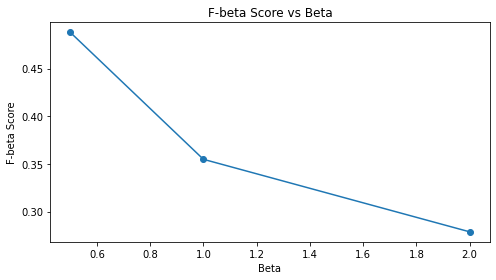

MCC: 0.2325
ROC AUC: 0.6807


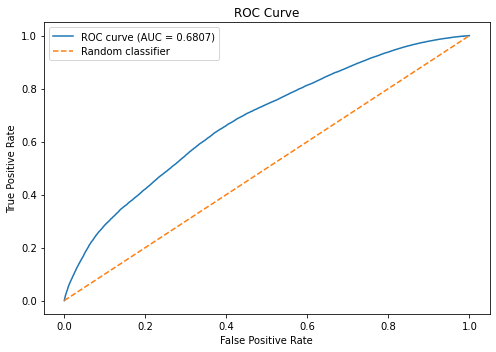

In [18]:
# F-beta: beta < 1 emphasizes precision; beta > 1 emphasizes recall
default_prediction = (oof_probability >= 0.5).astype(int)
betas = [0.5, 1.0, 2.0]
fbeta_table = pd.DataFrame({
    "Beta": betas,
    "F_beta": [
        fbeta_score(y_clf, default_prediction, beta=b, zero_division=0)
        for b in betas
    ]
})
display(fbeta_table.round(4))

plt.figure(figsize=(7, 4))
plt.plot(fbeta_table["Beta"], fbeta_table["F_beta"], marker="o")
plt.xlabel("Beta")
plt.ylabel("F-beta Score")
plt.title("F-beta Score vs Beta")
plt.tight_layout()
plt.show()

# MCC uses all four confusion-matrix cells
mcc = matthews_corrcoef(y_clf, default_prediction)
print("MCC:", round(mcc, 4))

# ROC-AUC evaluates probability ranking across all possible thresholds
auc = roc_auc_score(y_clf, oof_probability)
fpr, tpr, _ = roc_curve(y_clf, oof_probability)
print("ROC AUC:", round(auc, 4))

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
# Check whether representative operating thresholds behave consistently across folds
stability_rows = []
for fold, val_idx in fold_indices:
    y_val = y_clf.iloc[val_idx].to_numpy()
    p_val = oof_probability[val_idx]

    for threshold in [0.3, 0.5, 0.7]:
        pred = (p_val >= threshold).astype(int)
        stability_rows.append({
            "Fold": fold,
            "Threshold": threshold,
            "Precision": precision_score(y_val, pred, zero_division=0),
            "Recall": recall_score(y_val, pred, zero_division=0),
            "F1": f1_score(y_val, pred, zero_division=0)
        })

stability_table = pd.DataFrame(stability_rows)
display(stability_table.round(4))


,Fold,Threshold,Precision,Recall,F1
0,1,0.3,0.4665,0.7564,0.5771
1,1,0.5,0.6295,0.2967,0.4033
2,1,0.7,0.7624,0.0616,0.1140
3,2,0.3,0.4449,0.7999,0.5718
4,2,0.5,0.6536,0.2241,0.3338
5,2,0.7,0.7980,0.0102,0.0201
6,3,0.3,0.4648,0.7507,0.5741
7,3,0.5,0.6362,0.2833,0.3920
8,3,0.7,0.7683,0.0565,0.1053
9,4,0.3,0.4460,0.7977,0.5721


**Trade-off between false positives and false negatives**  
Increasing the classification threshold raises precision but sharply reduces recall, while lowering the threshold has the opposite effect. Among the required thresholds, 0.3 gives the highest F1-score (0.5749), with precision 0.4495 and recall 0.7973, compared with F1 = 0.3549 at threshold 0.5. At threshold 0.8, precision is high (0.8071) but recall falls to 0.0029; at 0.9 no positive predictions are produced.

At threshold 0.5, the F-beta scores are 0.4880 for β = 0.5, 0.3549 for β = 1, and 0.2788 for β = 2. The decline as more weight is placed on recall reflects the model's low recall at the default threshold. MCC is 0.2325, indicating positive but limited classification agreement, and ROC-AUC is 0.6807, showing moderate discrimination above random ranking.

**Stable and unstable operating regions**  
Threshold 0.3 is stable across the five folds: its F1-score remains approximately 0.572–0.579. Threshold 0.5 is consistently weaker, while threshold 0.7 is unstable because recall becomes very small and reaches zero in one fold. Therefore, 0.3 is the most stable and balanced operating point among the tested thresholds when F1 is the objective.


## 3.5 Discussion

**Strengths and limitations of the evaluated model in relation to the data**  
Logistic Regression provides probabilistic predictions and achieves moderate probability-ranking ability (ROC-AUC 0.6807). Its main limitation is very low recall for wins at the default threshold, together with only moderate overall discrimination.

**Key failure modes identified during the analysis**  
The dominant failure mode is false negatives: many actual wins are classified as non-wins. High-confidence false negatives also occur, and subgroup analysis shows degraded performance for home observations and some competitions.

**Relationship between model assumptions and observed performance**  
Logistic Regression represents the class relationship through a linear decision function in the encoded feature space. The available predictors mainly describe team identity, match context, and calendar information, so more complex or unexpected match outcomes may not be well represented. This is consistent with the model's moderate ROC-AUC and subgroup-dependent errors.

**Most significant insights from the study**  
The default threshold of 0.5 hides an important imbalance between precision and recall. Lowering the threshold to 0.3 substantially improves recall and F1, and the result is stable across folds. Confidence is informative on average but does not eliminate high-confidence mistakes.

**Recommendations for improving performance and robustness**  
Future work should consider richer pre-match predictors, evaluation of models capable of representing more complex relationships, and systematic threshold selection according to the desired false-positive/false-negative trade-off. Among the tested thresholds, 0.3 is preferred when F1 is the objective.


# 4. Final Reflection

**1. Where does the model fail most?**

The largest regression failures occur in the extreme-error subset and are disproportionately associated with some match contexts, particularly home observations and the FA Cup. In classification, the clearest failure at the default threshold is the large number of false negatives: many actual wins are classified as non-wins.

**2. Are failures due to data, model, or formulation?**

The failures reflect a combination of data representation, model limitations, and problem formulation. The predictors contain match context but limited information about team state immediately before a match. Linear Regression is not naturally suited to a discrete, non-negative goal count, and Logistic Regression at the default 0.5 threshold is poorly matched to win detection in this dataset. The analysis does not provide sufficient evidence that data-quality problems are the main cause.

**3. What improvements would you propose?**

Future work should consider richer pre-match predictors, models better suited to nonlinear relationships and the target type, and systematic hyperparameter evaluation. For classification, the threshold should be selected according to the required error trade-off; among the tested thresholds, 0.3 provides the best F1 balance and stable behavior across folds.

**4. What insights did you gain in your analysis?**

Model quality cannot be understood from a single aggregate metric. Residual analysis revealed heavy tails, extreme cases, and subgroup-dependent regression errors; model comparison showed that greater complexity did not guarantee better performance; and classification analysis showed that confusion-matrix structure, probability confidence, and threshold choice reveal important failure modes that an overall score can hide.
